## loading data



In [6]:


import pandas as pd    
import numpy as np     
import matplotlib.pyplot as plt   
import seaborn as sns              
from urllib.parse import unquote  
import joblib                             

sns.set_style('whitegrid')

df = pd.read_csv ('honeypot_training.csv', low_memory=False) 
df['dt'] =pd.to_datetime(df['@timestamp'], format='%b %d, %Y @ %H:%M:%S.%f', errors='coerce')  
print('Loaded my honeypot data:', len(df), 'rows')
print()
print('How many attacks each honeypot sensor caught:')
print(df['Type (type)'].value_counts()) 

Loaded my honeypot data: 108515 rows

How many attacks each honeypot sensor caught:
Type (type)
RDPHoneypot    64856
Cowrie         39972
Dionaea         2566
Heralding        600
Tanner           397
H0neytr4p        124
Name: count, dtype: int64


In [3]:


df = pd.read_csv('honeypot_training.csv', low_memory=False)
print(f'Loaded: {len(df)} rows, {len(df.columns)} columns')


cols_to_keep = [
    '@timestamp',
    'src_ip',
    'src_port',
    'DestPort (dest_port)',
    'Type (type)',
    'eventid',
    'session',
    'username',
    'password',
    'input',
    'message',
    'protocol',
    'geoip.country_name',
    'geoip.city_name',
    'geoip.location',
    'geoip.as_org',
    'T-Pot Hostname (t-pot_hostname)',
    'tags'
]


cols_available = [c for c in cols_to_keep if c in df.columns]
df_clean = df[cols_available].copy()


df_clean = df_clean.drop_duplicates()
print(f'After deduplication: {len(df_clean)} rows')


df_clean = df_clean.dropna(subset=['src_ip', 'Type (type)'], how='all')
print(f'After removing noise: {len(df_clean)} rows')


df_clean.to_csv('honeypot_clean.csv', index=False)
print(f'Saved as honeypot_clean.csv - {len(df_clean)} rows, {len(cols_available)} columns')

Loaded: 108515 rows, 378 columns
After deduplication: 108463 rows
After removing noise: 108463 rows
Saved as honeypot_clean.csv — 108463 rows, 18 columns


# Part 1  Threat Intelligence Analysis 
## Attacks by COUNTRY

geoip.country_name
Bulgaria           28995
Ukraine            20062
The Netherlands    17936
United States      17030
Indonesia           2498
Iran                2212
Vietnam             2200
United Kingdom      1993
Hong Kong           1832
South Korea         1598
Pakistan            1208
Peru                1125
Brazil              1064
China                841
Germany              796
Name: count, dtype: int64


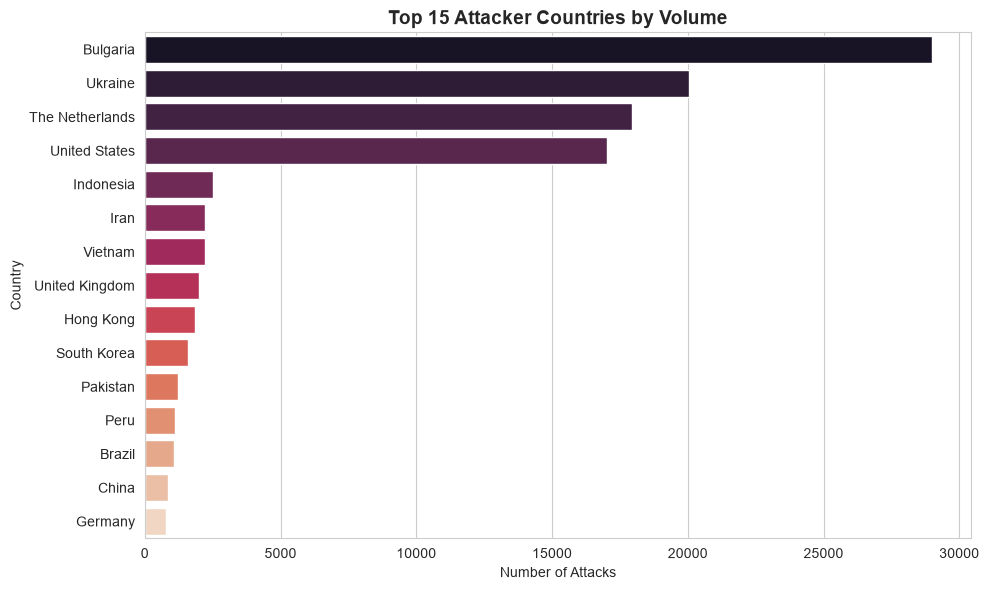

In [7]:
country_col = [c for c in df.columns if 'country_name' in c.lower()][0]   
top = df[country_col].value_counts().head(15)     
print (top)

plt.figure(figsize=(10, 6))
sns.barplot(x=top.values, y=top.index, hue=top.index, palette='rocket', legend=False) 
plt.title('Top 15 Attacker Countries by Volume', fontsize=14, fontweight='bold')
plt.xlabel('Number of Attacks'); plt.ylabel('Country')
plt.tight_layout(); plt.savefig('fig_top_countries.png', dpi=300, bbox_inches='tight') 
plt.show()



# top attacking ip address

src_ip
79.124.8.107      17124
88.210.63.75       8883
185.218.138.3      8368
94.26.88.29        8357
185.156.73.157     7503
78.128.112.114     3121
91.92.47.90        2603
5.181.86.179       1941
5.181.86.60        1734
91.109.113.43      1507
62.164.177.28      1483
45.156.87.204      1455
45.153.34.112      1261
45.156.87.254      1245
157.20.32.158      1132
Name: count, dtype: int64


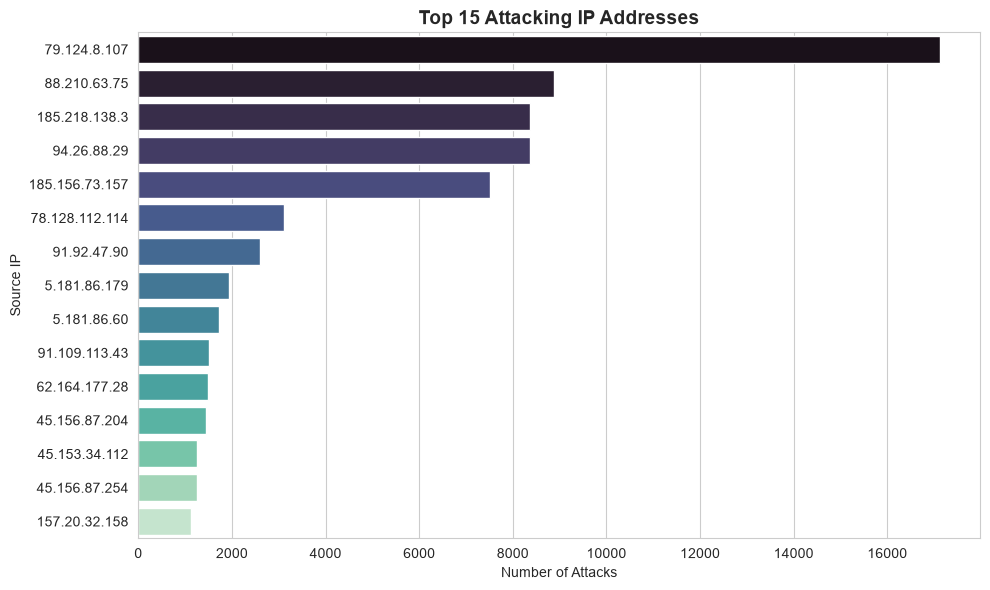

In [8]:
top_ips = df['src_ip'].value_counts().head(15)   
print(top_ips)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_ips.values, y=top_ips.index.astype(str), hue=top_ips.index.astype(str), palette='mako', legend=False)
plt.title('Top 15 Attacking IP Addresses', fontsize=14, fontweight='bold')
plt.xlabel('Number of Attacks'); plt.ylabel('Source IP')
plt.tight_layout(); plt.savefig('fig_top_ips.png', dpi=300, bbox_inches='tight')
plt.show()

#  Attack Volume Over Time

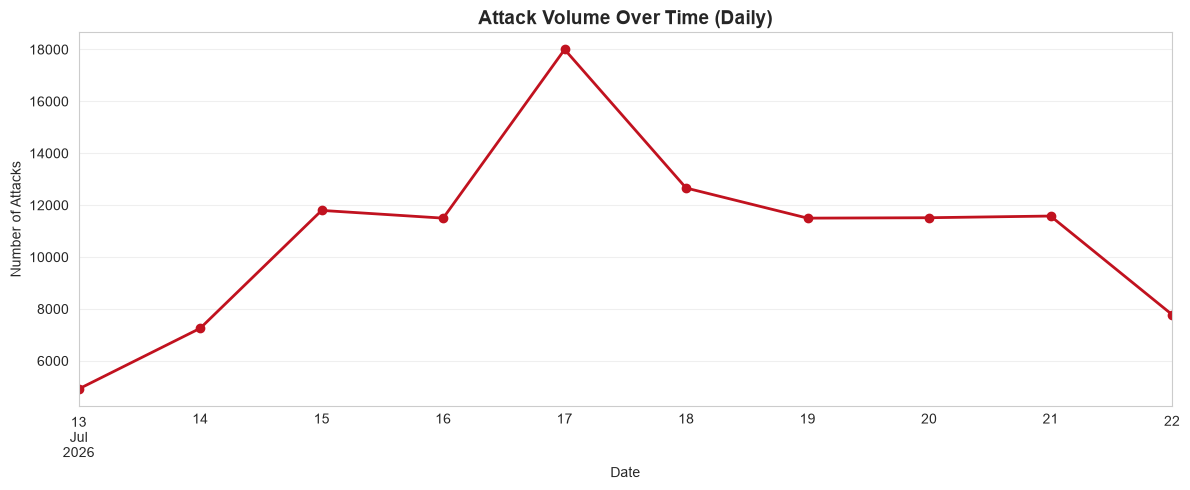

In [9]:

by_day = df.set_index('dt').resample('D').size()  
plt.figure(figsize=(12, 5))
by_day.plot(kind='line', marker='o', color='#c1121f', linewidth=2)
plt.title('Attack Volume Over Time (Daily)', fontsize=14, fontweight='bold')
plt.xlabel('Date'); plt.ylabel('Number of Attacks'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('fig_attacks_over_time.png', dpi=300, bbox_inches='tight') 
plt.show()

#  Brute-Force Credential Analysis

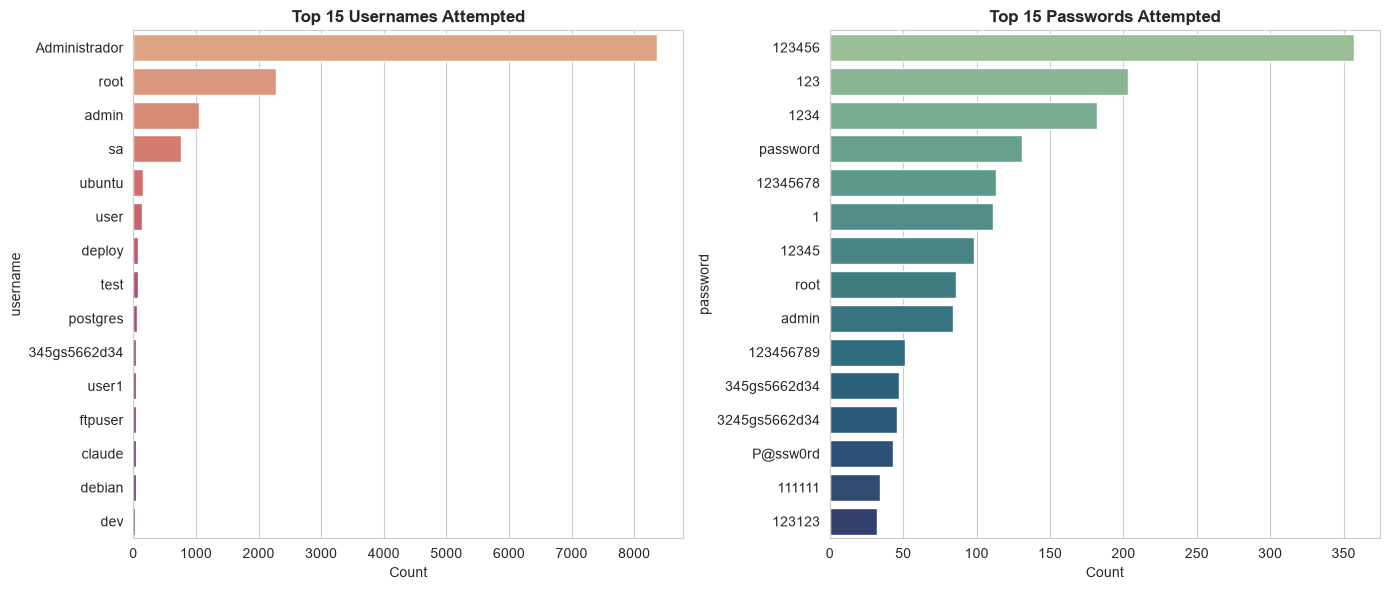

Total real credential attempts: 18231
Unique usernames tried: 2384
Unique passwords tried: 2396


In [10]:

def real_vals(series):    
    s = series.astype(str).str.strip()
    return s[~s.isin(['-', '', 'nan', 'NaN', '(blank)'])]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(x=tu.values, y=tu.index, hue=tu.index, palette='flare', legend=False, ax=axes[0])
axes[0].set_title('Top 15 Usernames Attempted', fontweight='bold'); axes[0].set_xlabel('Count')
tp = real_vals(df['password']).value_counts().head(15)  # top 15 passwords tried
sns.barplot(x=tp.values, y=tp.index, hue=tp.index, palette='crest', legend=False, ax=axes[1])
axes[1].set_title('Top 15 Passwords Attempted', fontweight='bold'); axes[1].set_xlabel('Count')
plt.tight_layout(); plt.savefig('fig_credentials.png', dpi=300, bbox_inches='tight')
plt.show()

print('Total real credential attempts:', len(real_vals(df['username'])))
print('Unique usernames tried:', real_vals(df['username']).nunique())
print('Unique passwords tried:', real_vals(df['password']).nunique())

# Targeted Ports and Services

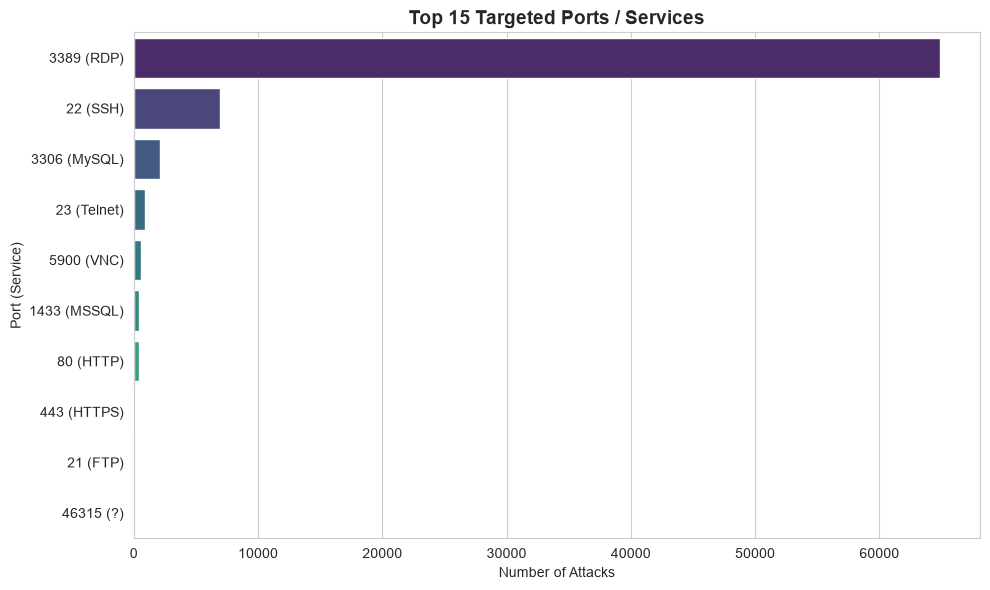

In [11]:


port_col = 'DestPort (dest_port)' if 'DestPort (dest_port)' in df.columns else [c for c in df.columns if 'dest_port' in c.lower()][0]  
ports = pd.to_numeric(df[port_col], errors='coerce').dropna().astype(int)  # keep only valid numeric ports
top_ports = ports.value_counts().head(15)
port_names = {22:'SSH', 3389:'RDP', 445:'SMB', 23:'Telnet', 80:'HTTP', 443:'HTTPS',
              3306:'MySQL', 1433:'MSSQL', 5900:'VNC', 21:'FTP', 25:'SMTP', 8080:'HTTP-alt'}  
labels = [f'{p} ({port_names.get(p, "?")})' for p in top_ports.index]    
plt.figure(figsize=(10, 6))
sns.barplot(x=top_ports.values, y=labels, hue=labels, palette='viridis', legend=False)
plt.title('Top 15 Targeted Ports / Services', fontsize=14, fontweight='bold')
plt.xlabel('Number of Attacks')
plt.ylabel('Port (Service)')
plt.tight_layout()
plt.savefig('fig_top_ports.png', dpi=300, bbox_inches='tight')
plt.show()

# Web Exploitation Attempts

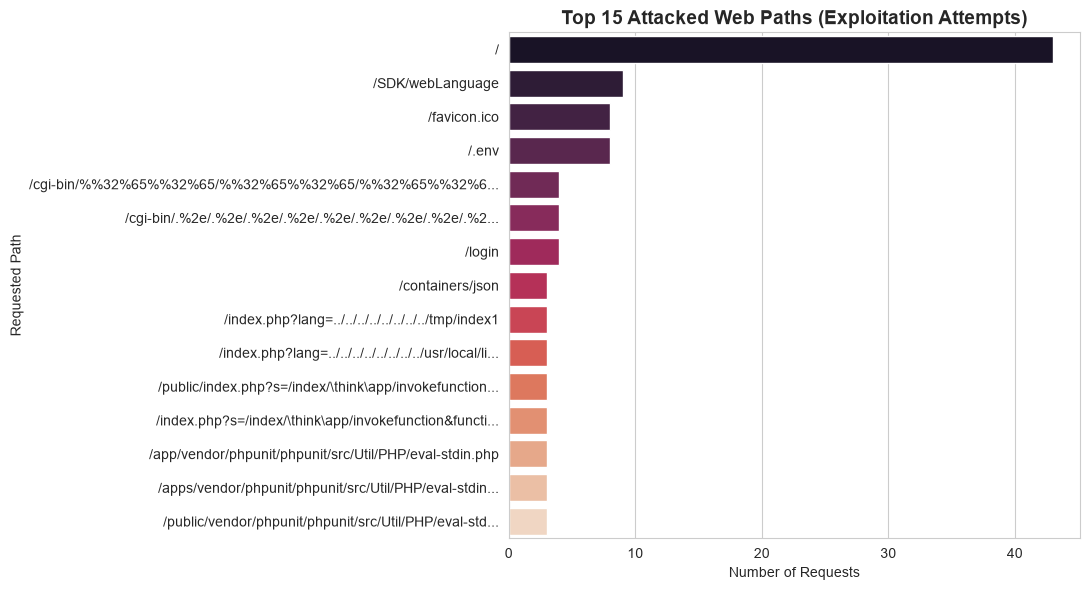

Total web requests: 397


In [12]:
#counts most requested url

web_all = df[df['Type (type)'].isin(['Tanner', 'H0neytr4p'])].copy()  # keep only the web honeypots
paths = web_all['path'].dropna().astype(str)  


paths = paths[paths != '/data/h0neytr4p/log/log.json']  # drop internal logfile noise
top_paths = paths.value_counts().head(15)
plt.figure(figsize=(11, 6))
plabels = [p if len(p) <= 55 else p[:52] + '...' for p in top_paths.index] 
sns.barplot(x=top_paths.values, y=plabels, hue=plabels, palette='rocket', legend=False)
plt.title('Top 15 Attacked Web Paths (Exploitation Attempts)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Requests'); plt.ylabel('Requested Path')
plt.tight_layout(); plt.savefig('fig_web_paths.png', dpi=300, bbox_inches='tight')
plt.show()
print('Total web requests:', len(paths))



##  MITRE ATT&CK Mapping

In [13]:
#Maps   attacks to MITRE  techniques
web = df[df['Type (type)'].isin(['Tanner', 'H0neytr4p'])].copy()  
web['request_decoded'] = web['path'].fillna('').astype(str).apply(lambda s: unquote(unquote(s)))  #new column that decode URL-encoded payloads

mitre_map = {
    'T1110 - Brute Force': int((df['Type (type)'].isin(['Cowrie', 'Heralding'])).sum()), 
    'T1190 - Exploit Public-Facing Application': int(web['request_decoded'].str.contains('eval-stdin|invokefunction|pearcmd', case=False, regex=True).sum()), 
    'T1083 - File and Directory Discovery': int(web['request_decoded'].str.contains(r'\.env|\.git|\.\./', regex=True).sum()),  
    'T1046 - Network Service Discovery': int((df['Type (type)'].isin(['RDPHoneypot', 'Dionaea'])).sum()),  # network scanning sensors
    'T1210 - Exploitation of Remote Services': int((df['Type (type)'] == 'Dionaea').sum()),
    'T1595 - Active Scanning': int(web['request_decoded'].str.contains('SDK/webLanguage|containers/json', regex=True).sum()),  # automated scanner fingerprints
}
print(' MITRE ATT&CK MAPPING (from my honeypot data) \n')
for tech, count in mitre_map.items():
    print(f'{tech}: {count:,} events observed')

 MITRE ATT&CK MAPPING (from my honeypot data) 

T1110 - Brute Force: 40,572 events observed
T1190 - Exploit Public-Facing Application: 120 events observed
T1083 - File and Directory Discovery: 186 events observed
T1046 - Network Service Discovery: 67,422 events observed
T1210 - Exploitation of Remote Services: 2,566 events observed
T1595 - Active Scanning: 12 events observed


# Part 2 ;  AI Attack Classifier
##  Load CSIC 2010 Dataset and Build Labels

In [14]:


csic = pd.read_csv('csic_database.csv', low_memory=False)  
csic['request_text'] = (csic['URL'].fillna('') + ' ' + csic['content'].fillna('')).astype(str) 
csic['request_decoded'] = csic['request_text'].apply(lambda s: unquote(unquote(s))) 

def label_attack(row): 
    if row['classification'] == 0:  
        return 'Normal'  ss
    t = row['request_decoded'].lower()
    if any(k in t for k in ['union select','or 1=1',"or '1'='1",'drop table','insert into','information_schema','select ','--',';--','concat(']): 
        return 'SQLi'
    if any(k in t for k in ['<script','javascript:','onerror=','onload=','alert(','<img','document.cookie','<svg']):
        return 'XSS'
    if any(k in t for k in ['../','..\\','%2e%2e','/etc/passwd','/bin/','boot.ini']):
        return 'Traversal'
    return 'Other-Anomalous' 
csic['attack_type'] = csic.apply(label_attack, axis=1)  
print('My labelled training data (the answer key the AI learns from):')
print(csic['attack_type'].value_counts())

My labelled training data (the answer key the AI learns from):
attack_type
Normal             36000
Other-Anomalous    21733
SQLi                1828
XSS                 1504
Name: count, dtype: int64


##  Feature Engineering (TF-IDF Character N-grams)

In [15]:


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

X_text = csic['request_decoded']  
y = csic['attack_type'] 
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y)  

vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(2, 4), max_features=5000)  
X_train = vectorizer.fit_transform(X_train_text)  
X_test = vectorizer.transform(X_test_text) 
print('Training examples:', X_train.shape[0])
print('Testing examples:', X_test.shape[0])
print('Numeric features per request:', X_train.shape[1])

Training examples: 48852
Testing examples: 12213
Numeric features per request: 5000


##  Train Random Forest Classifier

In [17]:

from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score #evaluation tools

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1) 
rf.fit(X_train, y_train)        

y_pred = rf.predict(X_test)       
print('Accuracy:', round(accuracy_score(y_test, y_pred), 4)) 
print()
print(classification_report(y_test, y_pred, digits=4)) 

Accuracy: 0.9699

                 precision    recall  f1-score   support

         Normal     0.9705    0.9786    0.9746      7200
Other-Anomalous     0.9641    0.9508    0.9574      4346
           SQLi     1.0000    1.0000    1.0000       366
            XSS     1.0000    1.0000    1.0000       301

       accuracy                         0.9699     12213
      macro avg     0.9836    0.9823    0.9830     12213
   weighted avg     0.9698    0.9699    0.9698     12213



##  Confusion Matrix

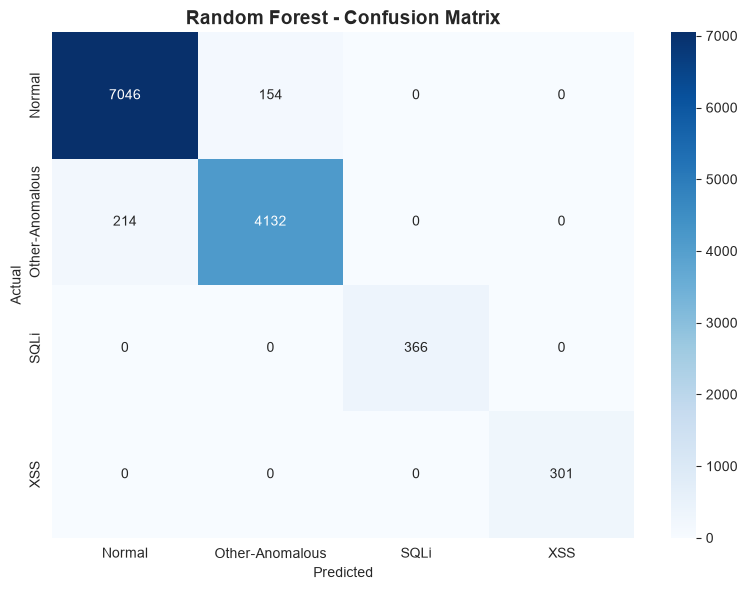

In [18]:

labels_order = ['Normal', 'Other-Anomalous', 'SQLi', 'XSS']
cm = confusion_matrix(y_test, y_pred, labels=labels_order)  
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_order, yticklabels=labels_order)
plt.title('Random Forest - Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.savefig('fig_rf_confusion.png', dpi=300, bbox_inches='tight')
plt.show()

##  Validation on Live Honeypot Data

In [19]:
live = df[df['Type (type)'].isin(['Tanner', 'H0neytr4p'])].copy()  
live['request_text'] = live['path'].fillna('').astype(str) #
if 'payload' in live.columns:
    live['request_text'] = live['request_text'] + ' ' + live['payload'].fillna('').astype(str) 
live['request_decoded'] = live['request_text'].apply(lambda s: unquote(unquote(s))) 
live = live[live['path'].astype(str) != '/data/h0neytr4p/log/log.json']  
X_live = vectorizer.transform(live['request_decoded'])   
live_pred = rf.predict(X_live)                            
proba = rf.predict_proba(X_live)                          
print('My real attacks fed to the AI:', len(live))
print()
print('How the AI classified them:')
print(pd.Series(live_pred).value_counts())
print()
print('Average confidence:', round(proba.max(axis=1).mean(), 3))
print()
print('The AI detected all as anomalous, but could not name the specific attack types.')
print(' This proves academic training data does not match real modern attacks.')

My real attacks fed to the AI: 397

How the AI classified them:
Other-Anomalous    397
Name: count, dtype: int64

Average confidence: 0.89

The AI detected all as anomalous, but could not name the specific attack types.
 This proves academic training data does not match real modern attacks.


##  Class Probability Distribution

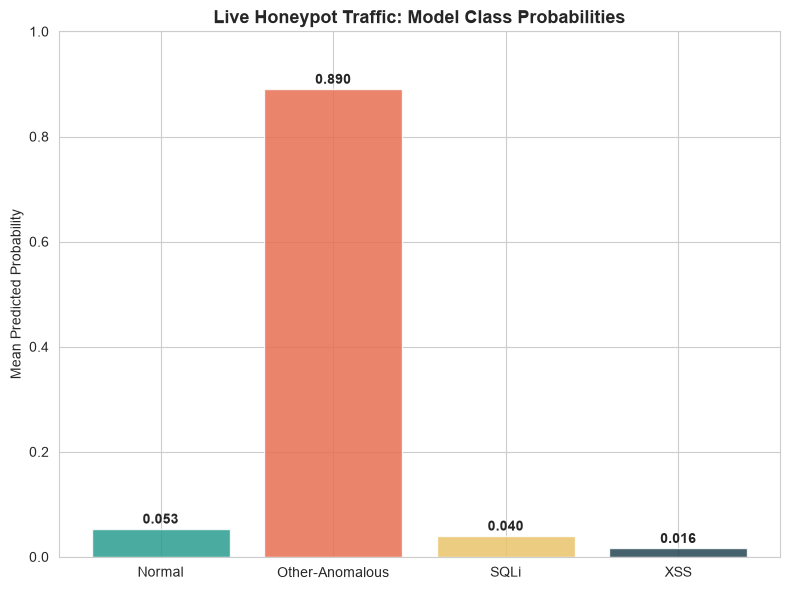

In [20]:
avg_proba = proba.mean(axis=0)  # average confidence per class across all real attacks
plt.figure(figsize=(8, 6))
bars = plt.bar(rf.classes_, avg_proba, color=['#2a9d8f','#e76f51','#e9c46a','#264653'], alpha=0.85)
plt.ylabel('Mean Predicted Probability'); plt.ylim(0, 1)
plt.title('Live Honeypot Traffic: Model Class Probabilities', fontsize=13, fontweight='bold')
for bar, p in zip(bars, avg_proba):
    plt.text(bar.get_x()+bar.get_width()/2, p+0.01, f'{p:.3f}', ha='center', fontweight='bold')
plt.tight_layout(); plt.savefig('fig_live_validation.png', dpi=300, bbox_inches='tight')
plt.show()

##  Prevention Decision Layer 

In [21]:

def ids_decision(request_text, model=rf, vec=vectorizer): 
    decoded = unquote(unquote(str(request_text)))  
    X = vec.transform([decoded])  
    pred = model.predict(X)[0] 
    conf = float(model.predict_proba(X).max()) 
    if pred == 'Normal':
        action = 'ALLOW'
    elif conf >= 0.90:
        action = 'BLOCK' 
    else:
        action = 'REVIEW' 
    return {'request': str(request_text)[:60], 'classification': pred, 'confidence': round(conf,3), 'action': action}

tests = [
    "/index.php?id=1' UNION SELECT username,password FROM users--",
    "/search?q=<script>alert('xss')</script>",
    "/app/vendor/phpunit/phpunit/src/Util/PHP/eval-stdin.php",
    "/products/index.jsp?category=books",
    "/.env",
] 
print(' PREVENTION DECISION DEMO \n')
for req in tests:
    r = ids_decision(req)
    print(f"[{r['action']:6s}] {r['classification']:16s} (conf {r['confidence']}) <- {r['request']}")

 PREVENTION DECISION DEMO 

[REVIEW] Other-Anomalous  (conf 0.79) <- /index.php?id=1' UNION SELECT username,password FROM users--
[REVIEW] XSS              (conf 0.82) <- /search?q=<script>alert('xss')</script>
[REVIEW] Other-Anomalous  (conf 0.88) <- /app/vendor/phpunit/phpunit/src/Util/PHP/eval-stdin.php
[REVIEW] Other-Anomalous  (conf 0.88) <- /products/index.jsp?category=books
[BLOCK ] Other-Anomalous  (conf 0.91) <- /.env


##  Save Trained Model

In [24]:
joblib.dump(rf, 'honeypot_rf_model.joblib')          
joblib.dump(vectorizer, 'honeypot_vectorizer.joblib')  
print('Saved: honeypot_rf_model.joblib and honeypot_vectorizer.joblib')
print('Done-the whole project has now run, step by step.')

Saved: honeypot_rf_model.joblib and honeypot_vectorizer.joblib
Done-the whole project has now run, step by step.


## Regular expression

In [25]:
import pandas as pd 
import re 
from urllib.parse import unquote 


csic = pd.read_csv('csic_database.csv', low_memory=False) 
csic['req'] = (csic['URL'].fillna('') + ' ' + csic['content'].fillna('')).astype(str).apply(lambda s: unquote(unquote(s))) 


sqli_re = re.compile(r"('\s*(or|and)\s|union\s+select|select\s.+\sfrom\s|;\s*drop\s+table|'\s*;|'--|--\s|/\*|information_schema|waitfor\s+delay)", re.I) 
xss_re  = re.compile(r'(<script|javascript:|onerror\s*=|onload\s*=|<img[^>]|<svg|alert\s*\()', re.I) 


def csic_label(row): 
    if row['classification'] == 0: 
        return 'Normal'
    t = row['req'] 
    if sqli_re.search(t): return 'SQLi'  
    if xss_re.search(t):  return 'XSS'  
    return None   

csic['label'] = csic.apply(csic_label, axis=1) 
normal = csic[csic['label']=='Normal'].sample(2000, random_state=42)[['req','label']]  
sqli   = csic[csic['label']=='SQLi'][['req','label']]
xss    = csic[csic['label']=='XSS'][['req','label']]

print("From CSIC:")
print("  Normal:", len(normal), " SQLi:", len(sqli), " XSS:", len(xss))





From CSIC:
  Normal: 2000  SQLi: 1316  XSS: 1504


# Adds 2 new classes from honey pot data
## 5 class extension

In [26]:

df = pd.read_csv('honeypot_training.csv', low_memory=False)
web = df[df['Type (type)'].isin(['Tanner','H0neytr4p'])].copy()  
web['req'] = web['path'].fillna('').astype(str) 
if 'payload' in web.columns: 
    web['req'] = web['req'] + ' ' + web['payload'].fillna('').astype(str) 
web['req'] = web['req'].apply(lambda s: unquote(unquote(s))) 
web = web[web['path'].astype(str) != '/data/h0neytr4p/log/log.json']  

rce_re = re.compile(r'(eval-stdin|invokefunction|pearcmd|/bin/sh|call_user_func)', re.I)  
sec_re = re.compile(r'(\.env|\.git|/\.aws|credentials|\.ssh)', re.I)  
def hlabel(t): 
    if rce_re.search(t): return 'RCE' 
    if sec_re.search(t): return 'Secret-Harvest'
    return None

web['label'] = web['req'].apply(hlabel)
honey = web[web['label'].notna()][['req','label']]  

# combine all five classes 
combined = pd.concat([normal, sqli, xss, honey], ignore_index=True) 
print("COMBINED TRAINING SET (my 5 classes) ")
print(combined['label'].value_counts())
print("\nTotal:", len(combined))

COMBINED TRAINING SET (my 5 classes) 
label
Normal            2000
XSS               1504
SQLi              1316
Secret-Harvest     173
RCE                128
Name: count, dtype: int64

Total: 5121


# Feature enginerring on combined classifier

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer 
from sklearn.model_selection import train_test_split


X_text = combined['req'] 
y = combined['label'] 
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y)  
vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(2, 4), max_features=5000)  #
X_train = vectorizer.fit_transform(X_train_text) 
X_test = vectorizer.transform(X_test_text) 
print("Training examples:", X_train.shape[0])
print("Testing examples:", X_test.shape[0])
print("Features per request:", X_train.shape[1])
print()
print("Classes in training set:")
print(y_train.value_counts())

Training examples: 4096
Testing examples: 1025
Features per request: 5000

Classes in training set:
label
Normal            1600
XSS               1203
SQLi              1053
Secret-Harvest     138
RCE                102
Name: count, dtype: int64


# 5 classifier training

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                            random_state=42, n_jobs=-1)  

y_pred = rf.predict(X_test)      
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4)) 
print(classification_report(y_test, y_pred, digits=4))  

Accuracy: 0.999

                precision    recall  f1-score   support

        Normal     0.9975    1.0000    0.9988       400
           RCE     1.0000    1.0000    1.0000        26
          SQLi     1.0000    0.9962    0.9981       263
Secret-Harvest     1.0000    1.0000    1.0000        35
           XSS     1.0000    1.0000    1.0000       301

      accuracy                         0.9990      1025
     macro avg     0.9995    0.9992    0.9994      1025
  weighted avg     0.9990    0.9990    0.9990      1025



# Confusion matrix - 5 classifier

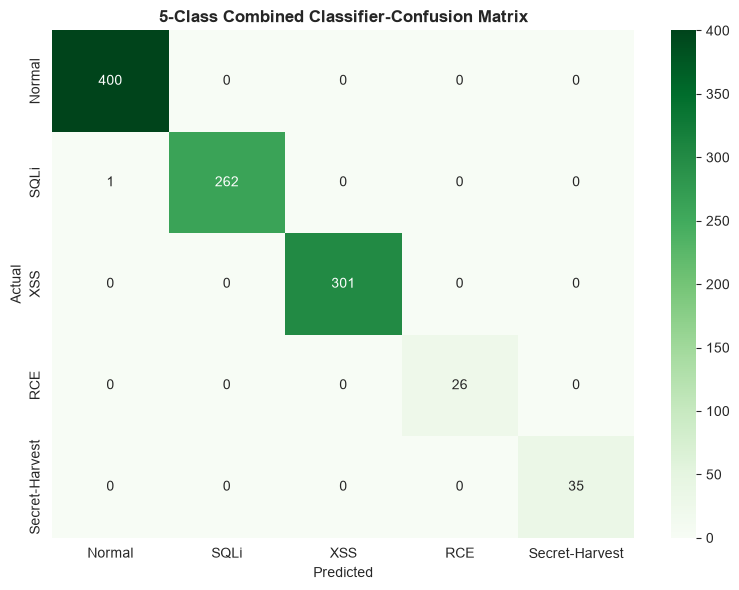

Saved fig_combined_confusion.png


In [30]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

order = ['Normal','SQLi','XSS','RCE','Secret-Harvest']
cm = confusion_matrix(y_test, y_pred, labels=order) 

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=order, yticklabels=order)
plt.title('5-Class Combined Classifier-Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('fig_combined_confusion.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved fig_combined_confusion.png")

# SAVE THE COMBINED 5-CLASS MODEL

In [31]:
import joblib
joblib.dump(rf, 'combined_5class_model.joblib')         
joblib.dump(vectorizer, 'combined_5class_vectorizer.joblib')  
print("Saved combined 5-class model + vectoriser")

Saved combined 5-class model + vectoriser


# Load 5-class model 

In [32]:
import joblib
from urllib.parse import unquote

model = joblib.load('combined_5class_model.joblib') 
vectorizer = joblib.load('combined_5class_vectorizer.joblib')

print("5-class model loaded - can classify: Normal, SQLi, XSS, RCE, Secret-Harvest")

5-class model loaded — can classify: Normal, SQLi, XSS, RCE, Secret-Harvest


# 5-class model IDS

In [33]:

def analyse(request):
    decoded = unquote(unquote(str(request)))  
    numbers = vectorizer.transform([decoded]) 
    label = model.predict(numbers)[0] 
    confidence = model.predict_proba(numbers).max() 

    if label == 'Normal':
        action = 'ALLOW'
    elif confidence >= 0.90:
        action = 'BLOCK'
    else:
        action = 'REVIEW'
    return label, confidence, action

def show(request):
    label, confidence, action = analyse(request)
    print("Request    :", request)
    print("Classified :", label)
    print("Confidence :", round(confidence, 2))
    print("DECISION   :", action)
    print("-" * 55)

print("Demo functions ready")

Demo functions ready


# 5-class model Live demo

In [34]:
X_demo = X_test_text.reset_index(drop=True) 
y_demo = y_test.reset_index(drop=True)

print("LIVE DEMO: classifying real unseen requests ")
print()
shown = set()  
for i in range(len(X_demo)):
    true_label = y_demo[i] 
    if true_label in shown:
        continue  
    request = X_demo[i] 
    numbers = vectorizer.transform([request])          
    label = model.predict(numbers)[0]                   
    confidence = model.predict_proba(numbers).max()    
    if label == 'Normal':
        action = 'ALLOW'
    elif confidence >= 0.90:
        action = 'BLOCK'                                
    else:
        action = 'REVIEW'                               
    mark = "correct" if label == true_label else "WRONG"
    print("Request    :", request[:70]) 
    print("True type  :", true_label, "  (" + mark + ")") 
    print("Classified :", label) 
    print("Confidence :", round(confidence, 2))
    print("DECISION   :", action)
    print("-" * 55)
    shown.add(true_label) 
    if len(shown) == 5: 
        break 

LIVE DEMO: classifying real unseen requests 

Request    : http://localhost:8080/tienda1/publico/autenticar.jsp HTTP/1.1 modo=ent
True type  : XSS   (correct)
Classified : XSS
Confidence : 1.0
DECISION   : BLOCK
-------------------------------------------------------
Request    : http://localhost:8080/tienda1/publico/caracteristicas.jsp HTTP/1.1 id=
True type  : Normal   (correct)
Classified : Normal
Confidence : 1.0
DECISION   : ALLOW
-------------------------------------------------------
Request    : http://localhost:8080/tienda1/publico/entrar.jsp?errorMsg=Credenciales
True type  : SQLi   (correct)
Classified : SQLi
Confidence : 1.0
DECISION   : BLOCK
-------------------------------------------------------
Request    : /.env.testing 
True type  : Secret-Harvest   (correct)
Classified : Secret-Harvest
Confidence : 1.0
DECISION   : BLOCK
-------------------------------------------------------
Request    : /lib/phpunit/phpunit/src/Util/PHP/eval-stdin.php 
True type  : RCE   (correct)
